In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cpp_benchmark_results.csv")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

for theta, group in df.groupby("theta"):
    group = group.sort_values("N")
    ax1.plot(group["N"], group["speedup"], marker="o", label=f"θ={theta}")
    ax2.plot(group["N"], group["avg_rel_error_pct"], marker="o", label=f"θ={theta}")
    ax3.plot(group["N"], group["barnes_hut_ms"], marker="o", label=f"BH θ={theta}")

# plot brute force once (same across thetas)
bf = df.drop_duplicates(subset="N").sort_values("N")
ax3.plot(bf["N"], bf["brute_force_ms"], marker="s", color="black", linestyle="--", label="Brute Force")

ax1.set_xscale("log")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Speedup (Brute Force / BH)")
ax1.set_title("CPU BH Speedup vs CPU BF")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xscale("log")
ax2.set_xlabel("Number of Bodies")
ax2.set_ylabel("Average Relative Force Error (%)")
ax2.set_title("Bh Approximation Error")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlabel("Number of Bodies")
ax3.set_ylabel("Runtime (ms)")
ax3.set_title("CPU BH vs BF Raw Runtime")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figs/cpu_benchmark_plots.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cuda_benchmark_results.csv")
df_seq_bh = pd.read_csv("cpp_bhut_only_benchmark_results.csv")

theta_colors = {0.5: "tab:orange", 1.0: "tab:green"}

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(26, 5))

for theta, group in df.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax1.plot(group["N"], group["speedup"], marker="o", label=f"θ={theta}", color=color)
    ax2.plot(group["N"], group["avg_rel_error_pct"], marker="o", label=f"θ={theta}", color=color)
    ax3.plot(group["N"], group["barnes_hut_ms"], marker="o", label=f"CUDA BH θ={theta}", color=color)

# plot brute force once (same across thetas)
bf = df.drop_duplicates(subset="N").sort_values("N")
ax3.plot(bf["N"], bf["brute_force_ms"], marker="s", color="black", linestyle="--", label="CUDA Brute Force")

# plot sequential CPU BH
for theta, group in df_seq_bh.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax3.plot(group["N"], group["barnes_hut_ms"], marker="^", linestyle=":", label=f"CPU BH θ={theta}", color=color)

# compute CUDA BH speedup over sequential CPU BH
merged = pd.merge(df, df_seq_bh, on=["N", "theta"], suffixes=("_cuda", "_cpu"))
merged["cpu_over_cuda"] = merged["barnes_hut_ms_cpu"] / merged["barnes_hut_ms_cuda"]

for theta, group in merged.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax4.plot(group["N"], group["cpu_over_cuda"], marker="o", label=f"θ={theta}", color=color)

ax1.set_xscale("log")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Cuda Speedup (Brute Force / BH)")
ax1.set_title("Cuda BH Speedup vs Cuda Brute Force")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xscale("log")
ax2.set_xlabel("Number of Bodies")
ax2.set_ylabel("Average Relative Force Error (%)")
ax2.set_title("Cuda BH Approximation Error")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlabel("Number of Bodies")
ax3.set_ylabel("Runtime (ms)")
ax3.set_title("Runtime: CPU BH vs CUDA Brute Force vs CUDA BH")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.set_xscale("log")
ax4.set_xlabel("Number of Bodies")
ax4.set_ylabel("Speedup (CPU BH / CUDA BH)")
ax4.set_title("CUDA BH Speedup vs CPU BH")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figs/cuda_benchmark_plotsv1.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cuda_kernel_times.csv")

kernels = ["body_reduce_ms", "build_tree_ms", "compute_cmass_ms", "compute_forces_ms", "apply_forces_ms"]
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]
labels = ["Bounding Box", "Build Tree", "Center of Mass", "Compute Forces", "Apply Forces"]

# ============================================================
# PLOT 1: Stacked bar by N, fixed theta=0.5
# ============================================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

df_t = df[df["theta"] == 0.5].sort_values("N")
x = np.arange(len(df_t))
width = 0.6
bottom = np.zeros(len(df_t))

for kern, color, label in zip(kernels, colors, labels):
    vals = df_t[kern].values
    ax1.bar(x, vals, width, bottom=bottom, color=color, label=label)
    bottom += vals

ax1.set_xticks(x)
ax1.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Time (ms)")
ax1.set_title("V1 Kernel Breakdown by N (θ=0.5)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figs/v1_profile_kernels_by_N.png", dpi=150)

# ============================================================
# PLOT 2: Stacked bar by theta, fixed N
# ============================================================
# pick the largest N that has all thetas
all_thetas = df["theta"].unique()
valid_N = df.groupby("N").filter(lambda g: set(all_thetas).issubset(set(g["theta"])))["N"].unique()
fixed_N = max(valid_N)

fig2, ax2 = plt.subplots(figsize=(8, 6))

df_n = df[df["N"] == fixed_N].sort_values("theta")
x = np.arange(len(df_n))
width = 0.5
bottom = np.zeros(len(df_n))

for kern, color, label in zip(kernels, colors, labels):
    vals = df_n[kern].values
    ax2.bar(x, vals, width, bottom=bottom, color=color, label=label)
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels([f"θ={t}" for t in df_n["theta"]])
ax2.set_xlabel("Theta")
ax2.set_ylabel("Time (ms)")
ax2.set_title(f"V1 Kernel Breakdown by θ (N={fixed_N:,})")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figs/v1_profile_kernels_by_theta.png", dpi=150)

# ============================================================
# PLOT 3: Kernel time vs total BH time (overhead analysis)
# ============================================================
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 6))

df_t = df[df["theta"] == 0.5].sort_values("N")
df_t["kernel_total_ms"] = df_t[kernels].sum(axis=1)
df_t["overhead_ms"] = df_t["barnes_hut_ms"] - df_t["kernel_total_ms"]
df_t["overhead_pct"] = df_t["overhead_ms"] / df_t["barnes_hut_ms"] * 100

# left: absolute times
x = np.arange(len(df_t))
width = 0.35
ax3a.bar(x - width/2, df_t["barnes_hut_ms"], width, label="Total BH Time", color="#4e79a7")
ax3a.bar(x + width/2, df_t["kernel_total_ms"], width, label="Kernel Time", color="#f28e2b")
ax3a.set_xticks(x)
ax3a.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax3a.set_xlabel("Number of Bodies")
ax3a.set_ylabel("Time (ms)")
ax3a.set_title("Total BH vs Kernel Time (θ=0.5)")
ax3a.legend()
ax3a.grid(True, alpha=0.3, axis="y")

# right: overhead percentage
ax3b.bar(x, df_t["overhead_pct"], color="#e15759")
ax3b.set_xticks(x)
ax3b.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax3b.set_xlabel("Number of Bodies")
ax3b.set_ylabel("Overhead (%)")
ax3b.set_title("V1 Non-Kernel Overhead (θ=0.5)")
ax3b.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax3b.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figs/v1_profile_overhead.png", dpi=150)

plt.show()

In [ ]:
# v2
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cuda_benchmark_resultsv2.csv")
df_seq_bh = pd.read_csv("cpp_bhut_only_benchmark_results.csv")

theta_colors = {0.5: "tab:orange", 1.0: "tab:green"}

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(26, 5))

for theta, group in df.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax1.plot(group["N"], group["speedup"], marker="o", label=f"θ={theta}", color=color)
    ax2.plot(group["N"], group["avg_rel_error_pct"], marker="o", label=f"θ={theta}", color=color)
    ax3.plot(group["N"], group["barnes_hut_ms"], marker="o", label=f"CUDA BH θ={theta}", color=color)

# plot brute force once (same across thetas)
bf = df.drop_duplicates(subset="N").sort_values("N")
ax3.plot(bf["N"], bf["brute_force_ms"], marker="s", color="black", linestyle="--", label="CUDA Brute Force")

# plot sequential CPU BH
for theta, group in df_seq_bh.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax3.plot(group["N"], group["barnes_hut_ms"], marker="^", linestyle=":", label=f"CPU BH θ={theta}", color=color)

# compute CUDA BH speedup over sequential CPU BH
merged = pd.merge(df, df_seq_bh, on=["N", "theta"], suffixes=("_cuda", "_cpu"))
merged["cpu_over_cuda"] = merged["barnes_hut_ms_cpu"] / merged["barnes_hut_ms_cuda"]

for theta, group in merged.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax4.plot(group["N"], group["cpu_over_cuda"], marker="o", label=f"θ={theta}", color=color)

ax1.set_xscale("log")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Cuda Speedup (Brute Force / BH)")
ax1.set_title("Cuda BH V2 Speedup vs Cuda BF")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xscale("log")
ax2.set_xlabel("Number of Bodies")
ax2.set_ylabel("Average Relative Force Error (%)")
ax2.set_title("Cuda BH V2 Approximation Error")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlabel("Number of Bodies")
ax3.set_ylabel("Runtime (ms)")
ax3.set_title("Runtime: CPU BH vs CUDA BF vs CUDA BH V2")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.set_xscale("log")
ax4.set_xlabel("Number of Bodies")
ax4.set_ylabel("Speedup (CPU BH / CUDA BH)")
ax4.set_title("CUDA BH V2 Speedup vs CPU BH")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figs/cuda_benchmark_plotsv2.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cuda_kernel_timesv2.csv")

kernels = ["body_reduce_ms", "build_tree_ms", "compute_cmass_ms", "compute_forces_ms", "apply_forces_ms"]
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]
labels = ["Bounding Box", "Build Tree", "Center of Mass", "Compute Forces", "Apply Forces"]

# ============================================================
# PLOT 1: Stacked bar by N, fixed theta=0.5
# ============================================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

df_t = df[df["theta"] == 0.5].sort_values("N")
x = np.arange(len(df_t))
width = 0.6
bottom = np.zeros(len(df_t))

for kern, color, label in zip(kernels, colors, labels):
    vals = df_t[kern].values
    ax1.bar(x, vals, width, bottom=bottom, color=color, label=label)
    bottom += vals

ax1.set_xticks(x)
ax1.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Time (ms)")
ax1.set_title("V2 Kernel Breakdown by N (θ=0.5)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figs/v2_profile_kernels_by_N.png", dpi=150)

# ============================================================
# PLOT 2: Stacked bar by theta, fixed N
# ============================================================
# pick the largest N that has all thetas
all_thetas = df["theta"].unique()
valid_N = df.groupby("N").filter(lambda g: set(all_thetas).issubset(set(g["theta"])))["N"].unique()
fixed_N = max(valid_N)

fig2, ax2 = plt.subplots(figsize=(8, 6))

df_n = df[df["N"] == fixed_N].sort_values("theta")
x = np.arange(len(df_n))
width = 0.5
bottom = np.zeros(len(df_n))

for kern, color, label in zip(kernels, colors, labels):
    vals = df_n[kern].values
    ax2.bar(x, vals, width, bottom=bottom, color=color, label=label)
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels([f"θ={t}" for t in df_n["theta"]])
ax2.set_xlabel("Theta")
ax2.set_ylabel("Time (ms)")
ax2.set_title(f"Kernel Breakdown by θ (N={fixed_N:,})")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figs/v2_profile_kernels_by_Theta.png", dpi=150)

# ============================================================
# PLOT 3: Kernel time vs total BH time (overhead analysis)
# ============================================================
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 6))

df_t = df[df["theta"] == 0.5].sort_values("N")
df_t["kernel_total_ms"] = df_t[kernels].sum(axis=1)
df_t["overhead_ms"] = df_t["barnes_hut_ms"] - df_t["kernel_total_ms"]
df_t["overhead_pct"] = df_t["overhead_ms"] / df_t["barnes_hut_ms"] * 100

# left: absolute times
x = np.arange(len(df_t))
width = 0.35
ax3a.bar(x - width/2, df_t["barnes_hut_ms"], width, label="Total BH Time", color="#4e79a7")
ax3a.bar(x + width/2, df_t["kernel_total_ms"], width, label="Kernel Time", color="#f28e2b")
ax3a.set_xticks(x)
ax3a.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax3a.set_xlabel("Number of Bodies")
ax3a.set_ylabel("Time (ms)")
ax3a.set_title("Total BH vs V2 Kernel Time (θ=0.5)")
ax3a.legend()
ax3a.grid(True, alpha=0.3, axis="y")

# right: overhead percentage
ax3b.bar(x, df_t["overhead_pct"], color="#e15759")
ax3b.set_xticks(x)
ax3b.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax3b.set_xlabel("Number of Bodies")
ax3b.set_ylabel("Overhead (%)")
ax3b.set_title("V2 Non-Kernel Overhead (θ=0.5)")
ax3b.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax3b.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figs/v2_profile_overhead.png", dpi=150)

plt.show()

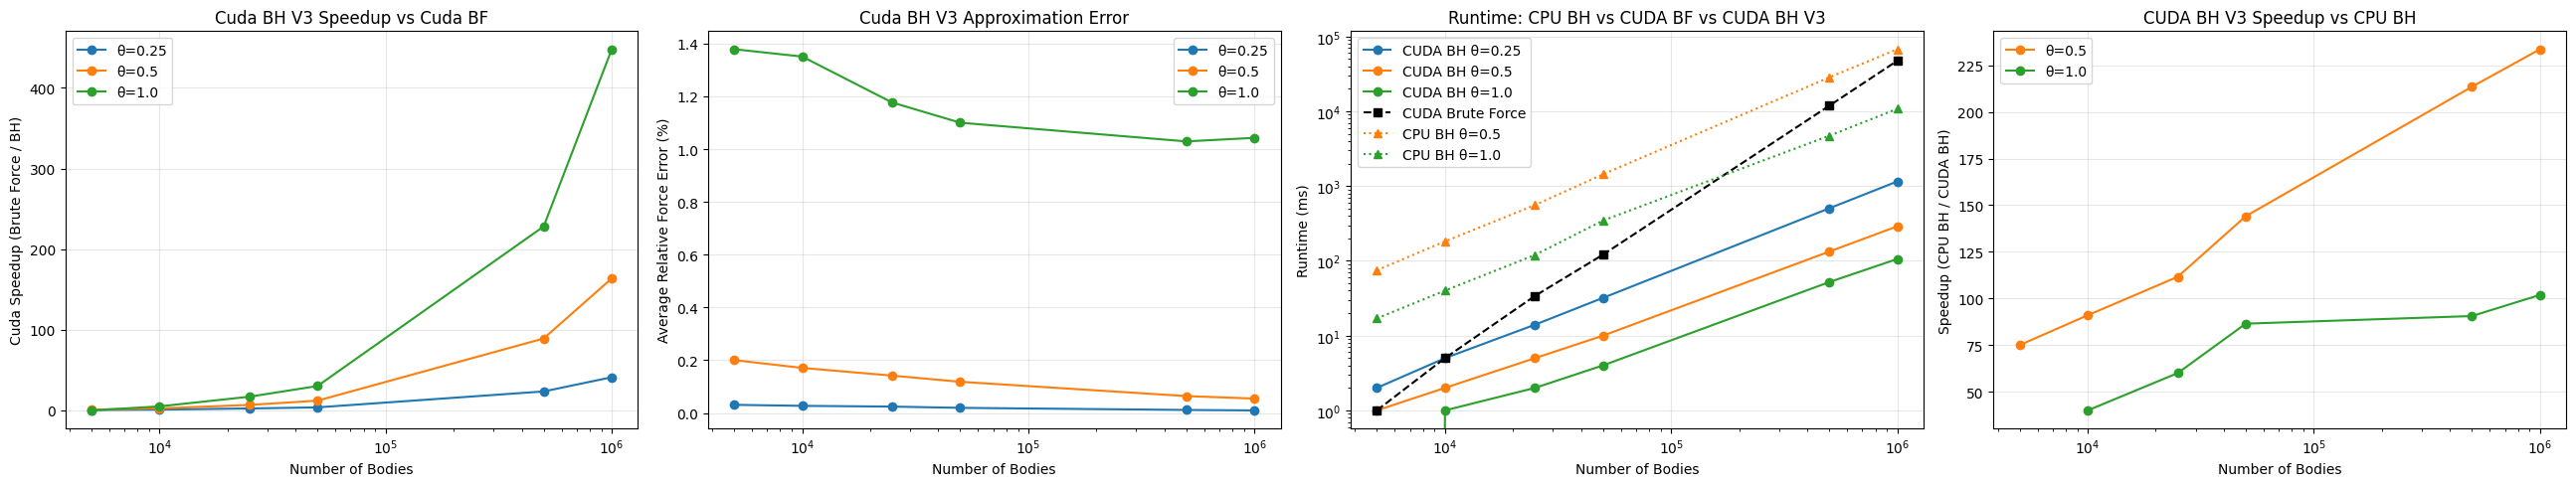

In [1]:
# v3
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cuda_benchmark_resultsv3.csv")
df_seq_bh = pd.read_csv("cpp_bhut_only_benchmark_results.csv")

theta_colors = {0.5: "tab:orange", 1.0: "tab:green"}

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(26, 5))

for theta, group in df.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax1.plot(group["N"], group["speedup"], marker="o", label=f"θ={theta}", color=color)
    ax2.plot(group["N"], group["avg_rel_error_pct"], marker="o", label=f"θ={theta}", color=color)
    ax3.plot(group["N"], group["barnes_hut_ms"], marker="o", label=f"CUDA BH θ={theta}", color=color)

# plot brute force once (same across thetas)
bf = df.drop_duplicates(subset="N").sort_values("N")
ax3.plot(bf["N"], bf["brute_force_ms"], marker="s", color="black", linestyle="--", label="CUDA Brute Force")

# plot sequential CPU BH
for theta, group in df_seq_bh.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax3.plot(group["N"], group["barnes_hut_ms"], marker="^", linestyle=":", label=f"CPU BH θ={theta}", color=color)

# compute CUDA BH speedup over sequential CPU BH
merged = pd.merge(df, df_seq_bh, on=["N", "theta"], suffixes=("_cuda", "_cpu"))
merged["cpu_over_cuda"] = merged["barnes_hut_ms_cpu"] / merged["barnes_hut_ms_cuda"]

for theta, group in merged.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax4.plot(group["N"], group["cpu_over_cuda"], marker="o", label=f"θ={theta}", color=color)

ax1.set_xscale("log")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Cuda Speedup (Brute Force / BH)")
ax1.set_title("Cuda BH V3 Speedup vs Cuda BF")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xscale("log")
ax2.set_xlabel("Number of Bodies")
ax2.set_ylabel("Average Relative Force Error (%)")
ax2.set_title("Cuda BH V3 Approximation Error")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlabel("Number of Bodies")
ax3.set_ylabel("Runtime (ms)")
ax3.set_title("Runtime: CPU BH vs CUDA BF vs CUDA BH V3")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.set_xscale("log")
ax4.set_xlabel("Number of Bodies")
ax4.set_ylabel("Speedup (CPU BH / CUDA BH)")
ax4.set_title("CUDA BH V3 Speedup vs CPU BH")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figs/cuda_benchmark_plotsv3.png", dpi=150)
plt.show()

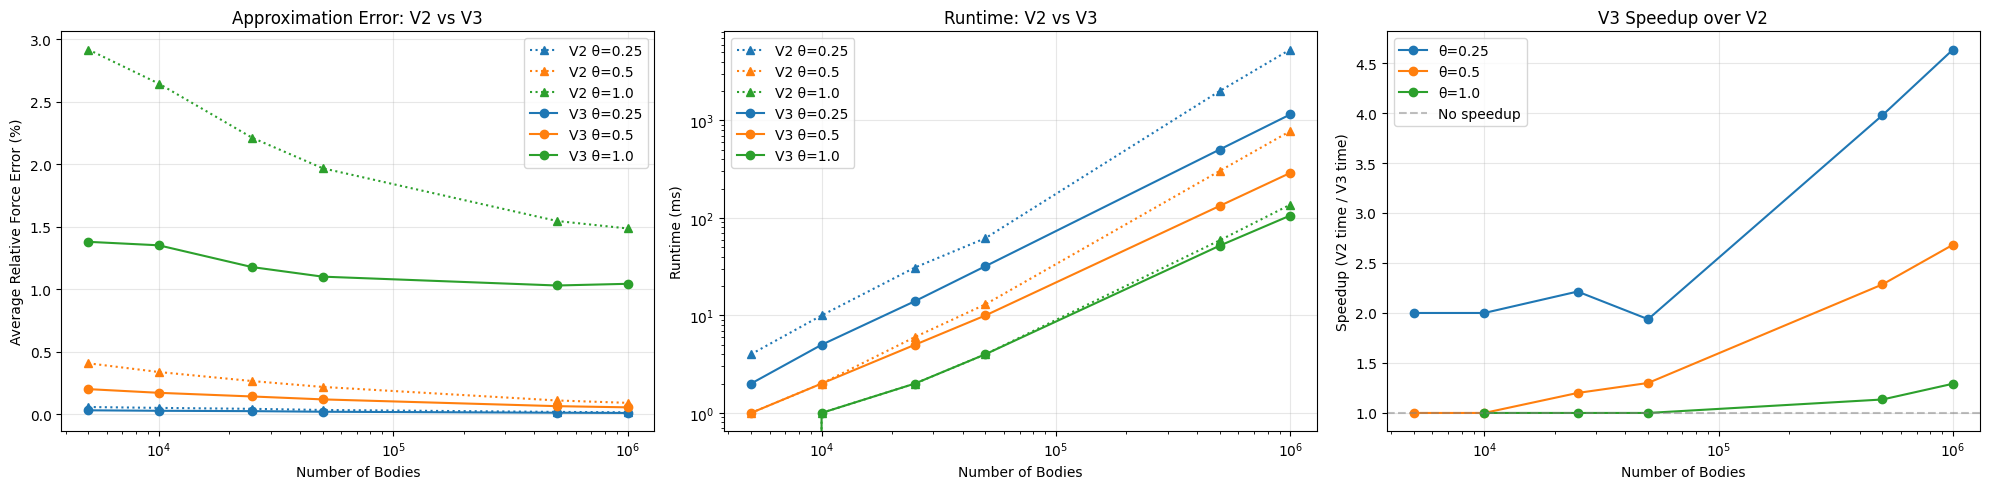

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df_v2 = pd.read_csv("cuda_benchmark_resultsv2.csv")
df_v3 = pd.read_csv("cuda_benchmark_resultsv3.csv")

theta_colors = {0.25: "tab:blue", 0.5: "tab:orange", 1.0: "tab:green"}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Approximation error comparison
for theta, group in df_v2.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax1.plot(group["N"], group["avg_rel_error_pct"], marker="^", linestyle=":", label=f"V2 θ={theta}", color=color)

for theta, group in df_v3.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax1.plot(group["N"], group["avg_rel_error_pct"], marker="o", label=f"V3 θ={theta}", color=color)

ax1.set_xscale("log")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Average Relative Force Error (%)")
ax1.set_title("Approximation Error: V2 vs V3")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Runtime comparison
for theta, group in df_v2.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax2.plot(group["N"], group["barnes_hut_ms"], marker="^", linestyle=":", label=f"V2 θ={theta}", color=color)

for theta, group in df_v3.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax2.plot(group["N"], group["barnes_hut_ms"], marker="o", label=f"V3 θ={theta}", color=color)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Number of Bodies")
ax2.set_ylabel("Runtime (ms)")
ax2.set_title("Runtime: V2 vs V3")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Speedup of V3 over V2
merged = pd.merge(df_v2, df_v3, on=["N", "theta"], suffixes=("_v2", "_v3"))
merged["v3_over_v2"] = merged["barnes_hut_ms_v2"] / merged["barnes_hut_ms_v3"]

for theta, group in merged.groupby("theta"):
    group = group.sort_values("N")
    color = theta_colors.get(theta)
    ax3.plot(group["N"], group["v3_over_v2"], marker="o", label=f"θ={theta}", color=color)

ax3.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="No speedup")
ax3.set_xscale("log")
ax3.set_xlabel("Number of Bodies")
ax3.set_ylabel("Speedup (V2 time / V3 time)")
ax3.set_title("V3 Speedup over V2")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figs/v2_vs_v3_comparison.png", dpi=150)
plt.show()

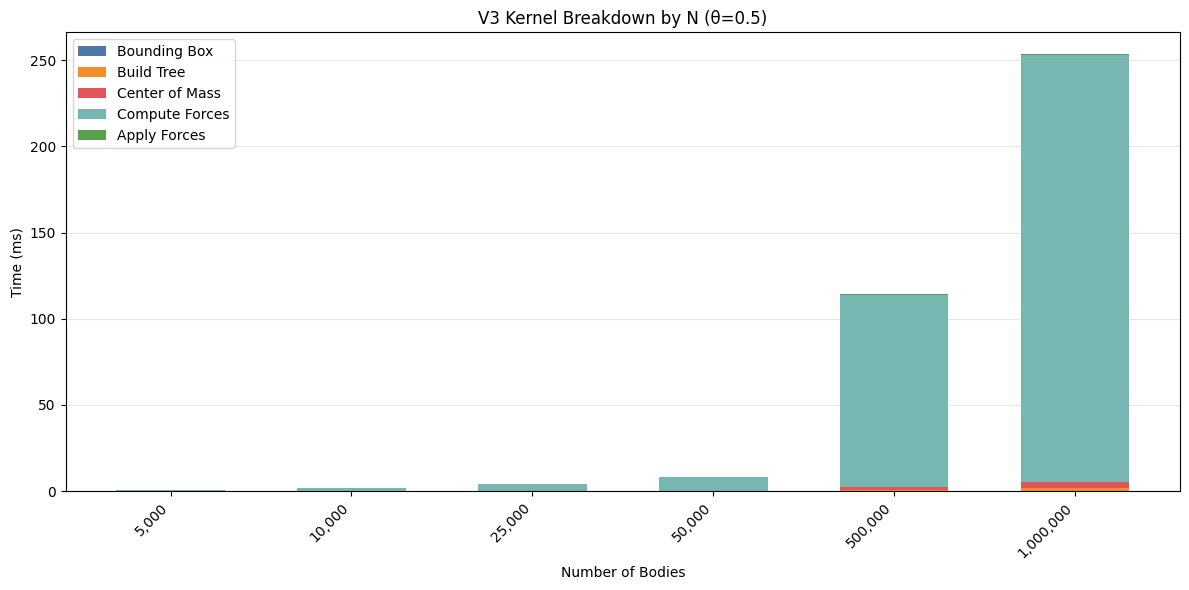

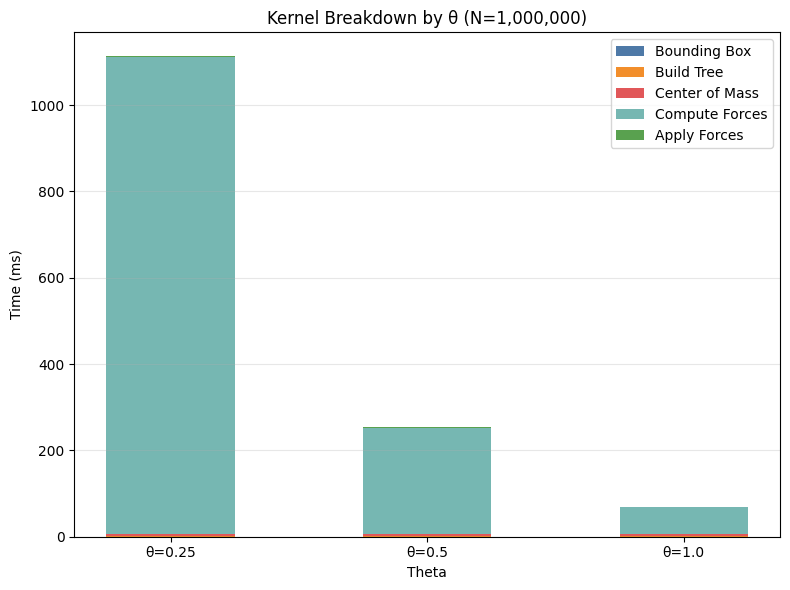

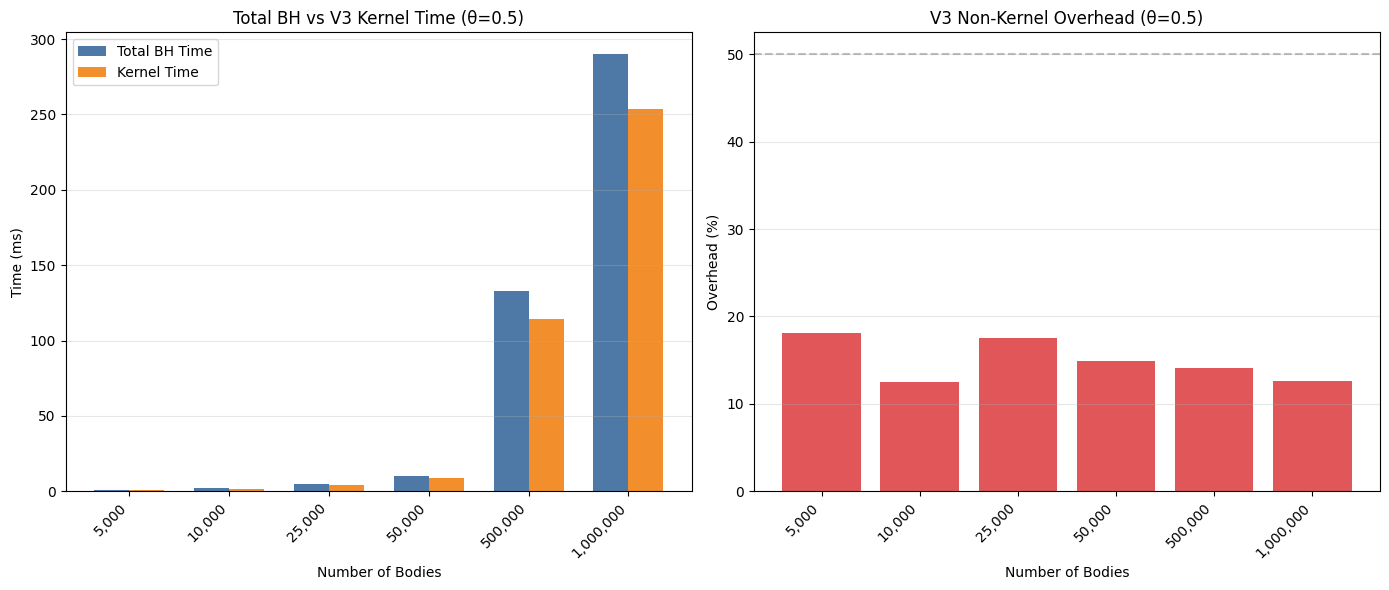

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cuda_kernel_timesv3.csv")

kernels = ["body_reduce_ms", "build_tree_ms", "compute_cmass_ms", "compute_forces_ms", "apply_forces_ms"]
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]
labels = ["Bounding Box", "Build Tree", "Center of Mass", "Compute Forces", "Apply Forces"]

# ============================================================
# PLOT 1: Stacked bar by N, fixed theta=0.5
# ============================================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

df_t = df[df["theta"] == 0.5].sort_values("N")
x = np.arange(len(df_t))
width = 0.6
bottom = np.zeros(len(df_t))

for kern, color, label in zip(kernels, colors, labels):
    vals = df_t[kern].values
    ax1.bar(x, vals, width, bottom=bottom, color=color, label=label)
    bottom += vals

ax1.set_xticks(x)
ax1.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax1.set_xlabel("Number of Bodies")
ax1.set_ylabel("Time (ms)")
ax1.set_title("V3 Kernel Breakdown by N (θ=0.5)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figs/v3_profile_kernels_by_N.png", dpi=150)

# ============================================================
# PLOT 2: Stacked bar by theta, fixed N
# ============================================================
# pick the largest N that has all thetas
all_thetas = df["theta"].unique()
valid_N = df.groupby("N").filter(lambda g: set(all_thetas).issubset(set(g["theta"])))["N"].unique()
fixed_N = max(valid_N)

fig2, ax2 = plt.subplots(figsize=(8, 6))

df_n = df[df["N"] == fixed_N].sort_values("theta")
x = np.arange(len(df_n))
width = 0.5
bottom = np.zeros(len(df_n))

for kern, color, label in zip(kernels, colors, labels):
    vals = df_n[kern].values
    ax2.bar(x, vals, width, bottom=bottom, color=color, label=label)
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels([f"θ={t}" for t in df_n["theta"]])
ax2.set_xlabel("Theta")
ax2.set_ylabel("Time (ms)")
ax2.set_title(f"Kernel Breakdown by θ (N={fixed_N:,})")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figs/v3_profile_kernels_by_Theta.png", dpi=150)

# ============================================================
# PLOT 3: Kernel time vs total BH time (overhead analysis)
# ============================================================
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 6))

df_t = df[df["theta"] == 0.5].sort_values("N")
df_t["kernel_total_ms"] = df_t[kernels].sum(axis=1)
df_t["overhead_ms"] = df_t["barnes_hut_ms"] - df_t["kernel_total_ms"]
df_t["overhead_pct"] = df_t["overhead_ms"] / df_t["barnes_hut_ms"] * 100

# left: absolute times
x = np.arange(len(df_t))
width = 0.35
ax3a.bar(x - width/2, df_t["barnes_hut_ms"], width, label="Total BH Time", color="#4e79a7")
ax3a.bar(x + width/2, df_t["kernel_total_ms"], width, label="Kernel Time", color="#f28e2b")
ax3a.set_xticks(x)
ax3a.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax3a.set_xlabel("Number of Bodies")
ax3a.set_ylabel("Time (ms)")
ax3a.set_title("Total BH vs V3 Kernel Time (θ=0.5)")
ax3a.legend()
ax3a.grid(True, alpha=0.3, axis="y")

# right: overhead percentage
ax3b.bar(x, df_t["overhead_pct"], color="#e15759")
ax3b.set_xticks(x)
ax3b.set_xticklabels([f"{n:,}" for n in df_t["N"]], rotation=45, ha="right")
ax3b.set_xlabel("Number of Bodies")
ax3b.set_ylabel("Overhead (%)")
ax3b.set_title("V3 Non-Kernel Overhead (θ=0.5)")
ax3b.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax3b.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figs/v3_profile_overhead.png", dpi=150)

plt.show()